# Implementing basic Chemprop model

In [ ]:
# import necessary libraries
import sys
from pathlib import Path

import numpy as np
import pandas as pd

from lightning import pytorch as pl

from chemprop import data, featurizers, models, nn
from chemprop.models.utils import save_model

Setting up local imports of custom python functions

In [2]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Also add the shared directory so that `utils` package can be resolved (matches streamlit_app logic)
SHARED_DIR = PROJECT_ROOT / 'shared'
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor


In [49]:
from src.base_uilts import get_performance_metrics, plot_xy_trend

# Reading data
First we read data for SMILES notation and corresponding log(Tg) value for all 902 polymers

In [ ]:
input_data_path = PROJECT_ROOT / 'data' / 'processed' / 'Tg_vs_SMILES_all.csv'
df_input = pd.read_csv(input_data_path)
print("Data-frame shape", df_input.shape)
df_input.head()

Data-frame with polymer's smile notation and corresponding log(Tg) values (902, 11)


,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N


In [ ]:
smiles_column = 'SMILES_clean' # column with SMILES notation strings
target_column = ['logTg'] # column with target variable value

## Prepping training data
Now we prepare data-set to be provided to neural network for model training

In [51]:
# get data-frame with training data IDs
train_df = pd.read_csv(
    PROJECT_ROOT / 'data' / 'raw' / 'data_902_original_15desc_logTg_train.csv'
)

# filter input table with IDs within training set
df_smiles_train = df_input[
    df_input['ID'].isin(train_df['Index'])
].reset_index(drop=True)

print("Training data-frame w/ SMILES notation", df_smiles_train.shape)

Training data-frame w/ SMILES notation (683, 11)


In [55]:
# converting input data to numpy array for downstream processing
train_smis = df_smiles_train.loc[:, smiles_column].values
print("Input smiles array shape", train_smis.shape)
print(train_smis[:5])

Input smiles array shape (683,)
['C=CC(=C)Cl' 'C=CC(N)=O' 'C=CC(=O)OCC(C#N)CC' 'C=CC(=O)OCC#N'
 'C=CC(=O)OCCCCCCCCCCCCCCCCCC']


In [48]:
# converting target data to numpy array
train_ys = df_smiles_train.loc[:, target_column].values
print("Target value array shape", train_ys.shape)
train_ys[:5]

Target value array shape (683, 1)


array([[2.7077],
       [2.852 ],
       [2.8177],
       [2.7552],
       [2.7687]])

In [ ]:
# MoleculeDatapoints, made from target value(s) and SMILES 
train_data = [
    data.MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(train_smis, train_ys)
]

# featurizer to transforms molecules into molecular graphs where atoms become nodes and bonds become edges
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

# define dataset of molecules and it's features
train_dset = data.MoleculeDataset(train_data, featurizer)

# normalizing target variable values for better model fit
scaler = train_dset.normalize_targets()

# define a data loader to be passed to the neural network
train_loader = data.build_dataloader(
    train_dset, # training dataset of molecules
    batch_size=64, # count of data-points to use in each training iteration
    num_workers=20 # number of workers for multi-processing
)

# Model training

## Define Message-Passing Neural Network (MPNN)
Constructing a molecular graph using message passing to learn **bond-level hidden representations**

In [ ]:
mp = nn.BondMessagePassing()

Other option is to do message passing at Atom-level

In [43]:
nn.AtomMessagePassing

chemprop.nn.message_passing.base.AtomMessagePassing

**Aggregation** is responsible for constructing a graph-level representation from the set of node-level representations after message passing. We select mean aggregation but here are all available options.

In [56]:
print(nn.agg.AggregationRegistry)

ClassRegistry {
    'mean': <class 'chemprop.nn.agg.MeanAggregation'>,
    'sum': <class 'chemprop.nn.agg.SumAggregation'>,
    'norm': <class 'chemprop.nn.agg.NormAggregation'>
}


In [57]:
agg = nn.MeanAggregation()

In [26]:
# A Batch Norm normalizes the outputs of the aggregation by re-centering and re-scaling.
batch_norm = True

In [22]:
print(nn.PredictorRegistry)

ClassRegistry {
    'regression': <class 'chemprop.nn.predictors.RegressionFFN'>,
    'regression-mve': <class 'chemprop.nn.predictors.MveFFN'>,
    'regression-evidential': <class 'chemprop.nn.predictors.EvidentialFFN'>,
    'regression-quantile': <class 'chemprop.nn.predictors.QuantileFFN'>,
    'classification': <class 'chemprop.nn.predictors.BinaryClassificationFFN'>,
    'classification-dirichlet': <class 'chemprop.nn.predictors.BinaryDirichletFFN'>,
    'multiclass': <class 'chemprop.nn.predictors.MulticlassClassificationFFN'>,
    'multiclass-dirichlet': <class 'chemprop.nn.predictors.MulticlassDirichletFFN'>,
    'spectral': <class 'chemprop.nn.predictors.SpectralFFN'>
}


In [23]:
# nn.UnscaleTransform.from_standard_scaler creates a transform that can be used to unscale model outputs
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)

In [24]:
ffn = nn.RegressionFFN(output_transform=output_transform)

In [ ]:
mpnn = models.MPNN(mp, agg, ffn, batch_norm)
mpnn

## Trainer a MPNN model

In [ ]:
trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=False, # Use `True` if you want to save model checkpoints. 
    enable_progress_bar=True,
    accelerator="auto",
    devices=1, # 
    max_epochs=50, # number of epochs to train for
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [31]:
trainer.fit(mpnn, train_loader)

/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name            | Type               | Params | Mode 
---------------------------------------------------------------
0 | message_passing | BondMessagePassing | 227 K  | train
1 | agg             | MeanAggregation    | 0      | train
2 | bn              | Batch

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [ ]:
trainer.callback_metrics

## Model prediction on training data

In [ ]:
train_

In [ ]:
train_preds = trainer.predict(mpnn, test_loader)

In [ ]:
# add a generic code for R2 score and rmse calc.
get_performance_metrics(
    y_true=,
    y_pred=
)

In [ ]:
# scatter plot for y_true versus y_pred

# Validating model on an independent dataset

In [ ]:
df_smiles_test = df_input[~df_input['ID'].isin(train_df['Index'])].reset_index(drop=True)
df_smiles_test.shape
test_smis = df_smiles_test[smiles_column]
test_smis[:5]

In [37]:
test_data = [data.MoleculeDatapoint.from_smi(smi) for smi in test_smis]
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
test_dset = data.MoleculeDataset(test_data, featurizer=featurizer)
test_loader = data.build_dataloader(test_dset, shuffle=False)

In [38]:
test_preds = trainer.predict(mpnn, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
test_preds.shape

In [ ]:
test_preds = np.concatenate(test_preds, axis=0)

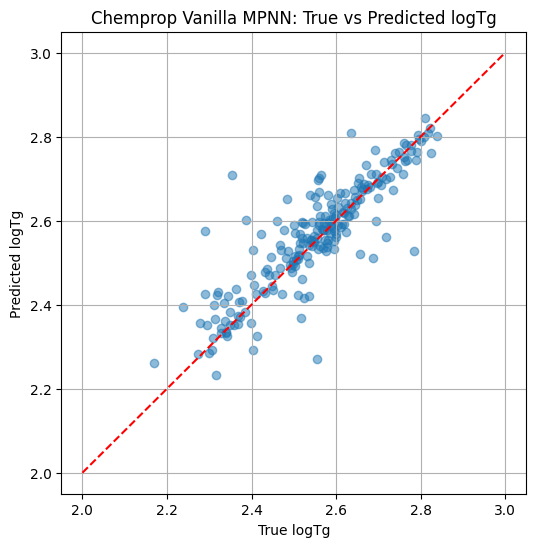

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(df_smiles_test['logTg'], df_smiles_test['pred'], alpha=0.5)
plt.plot([2,3], [2,3], color='red', linestyle='--')
plt.xlabel('True logTg')
plt.ylabel('Predicted logTg')
plt.title('Chemprop Vanilla MPNN: True vs Predicted logTg')
plt.grid(True)
plt.show()

# Save the trained model

In [ ]:
model_save_path = PROJECT_ROOT / 'data' / 'processed' /'chemprop_vanilla_mpnn_model.pickle'
save_model(model_save_path, mpnn)